# EDA de `merged_datasets`
Exploraremos el dataset combinado paso a paso. El objetivo es entender:
- la distribución de tipos (`Type`)
- los grupos de características `f_`, `t_`, `w_`
- qué variables parecen separar mejor los eventos sísmicos

A medida que avancemos, plantearé preguntas para definir el siguiente análisis.

In [17]:
# Cargar librerías y datos
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)

path = os.path.join(r'c:\Users\ricar\OneDrive\Desktop\TESIS', 'merged_datasets.json')
with open(path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
print('shape:', df.shape)
print('columnas:', len(df.columns))
print('tipos de datos:\n', df.dtypes.value_counts())

shape: (23827, 85)
columnas: 85
tipos de datos:
 float64    84
object      1
Name: count, dtype: int64


Conteo de eventos por Type:
Type
LP           12597
VT            8857
TREMI          712
HB             541
TRE            252
VLP            211
VLP_TYPE1      205
TRESP          185
VLP_TYPE2      132
EXPL            87
REGIONAL        27
TRBA            14
ICEQUAKE         7
Name: count, dtype: int64
f_: 21 columnas
t_: 13 columnas
w_: 50 columnas


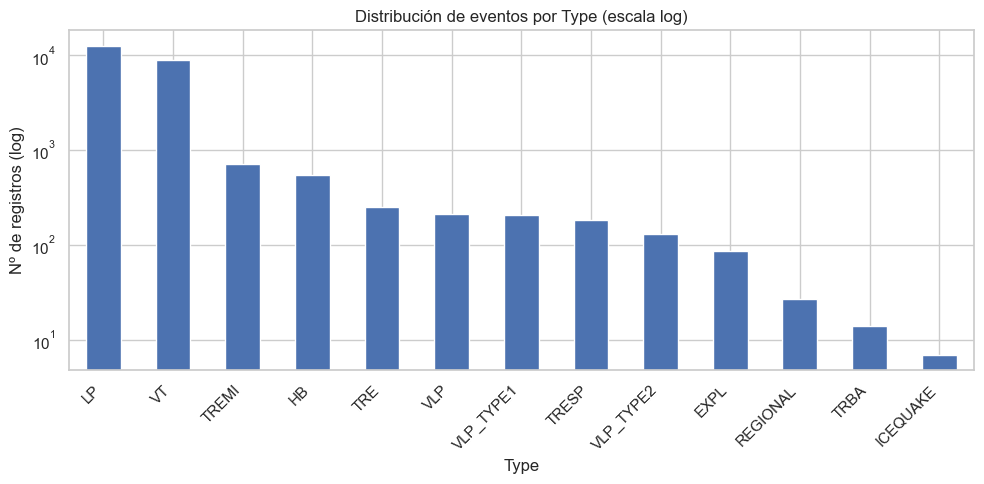

In [18]:
# Resumen de la etiqueta Type y grupos de características
print('Conteo de eventos por Type:')
counts = df['Type'].value_counts()
print(counts)

prefixes = {
    'f_': [c for c in df.columns if c.startswith('f_')],
    't_': [c for c in df.columns if c.startswith('t_')],
    'w_': [c for c in df.columns if c.startswith('w_')]
}
for prefix, cols in prefixes.items():
    print(f"{prefix}: {len(cols)} columnas")

plt.figure(figsize=(10, 5))
counts.plot(kind='bar')
plt.yscale('log')
plt.title('Distribución de eventos por Type (escala log)')
plt.ylabel('Nº de registros (log)')
plt.xlabel('Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Estadísticas básicas de grupos de características
summary = []
for prefix, cols in prefixes.items():
    subset = df[cols].select_dtypes(include=[np.number])
    summary.append({
        'grupo': prefix,
        'n_features': subset.shape[1],
        'mean_of_means': subset.mean().mean(),
        'mean_of_stds': subset.std(ddof=0).mean(),
        'max_variance': subset.var(ddof=0).max(),
        'min_variance': subset.var(ddof=0).min()
    })

summary_df = pd.DataFrame(summary)
summary_df

,grupo,n_features,mean_of_means,mean_of_stds,max_variance,min_variance
0,f_,21,-424617.596807,166158.820020,1.217191e+13,0.000385
1,t_,13,34.034697,64.811702,2.227986e+05,0.000425
2,w_,50,-9.686424,5.753680,3.600969e+03,0.000322


In [20]:
# Buscar características más variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
variances = df[numeric_cols].var(ddof=0).sort_values(ascending=False)
print('Top 10 características por varianza:')
print(variances.head(10))

# (Se eliminó la gráfica de comparación LP vs VT por petición del usuario)

Top 10 características por varianza:
f_entropy           1.217191e+13
t_entropy           2.227986e+05
f_energy            1.071793e+05
t_energy            1.071793e+05
f_var               1.424479e+04
w_t_meanEnergyAD    3.600969e+03
t_time2peak         1.321276e+03
w_t_PEC_A6          1.252653e+03
w_t_PEC_D3          4.927989e+02
w_f_maxval_A6       2.252262e+02
dtype: float64


UMAP no disponible o error en dependencias: Numba needs NumPy 2.1 or less. Got NumPy 2.3.
Usando t-SNE como fallback para visualización (más lento).


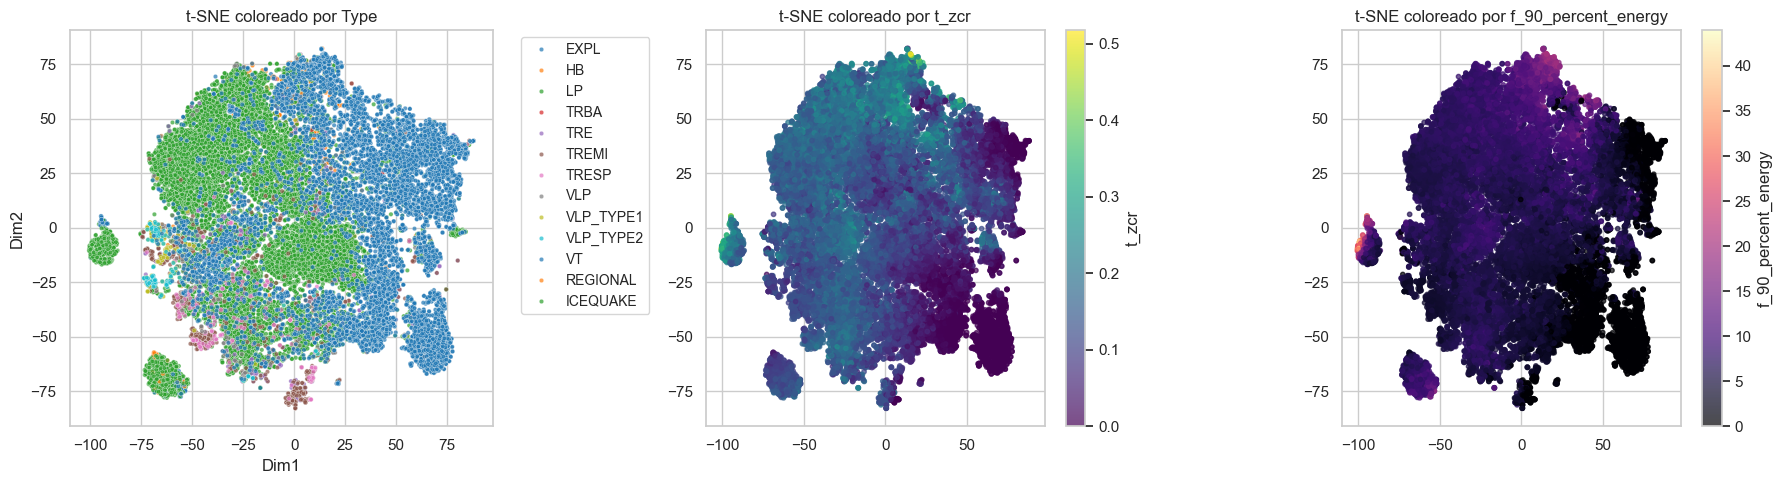

In [ ]:
# UMAP para visualizaciones: tres gráficos en figuras distintas coloreados por Type, t_zcr y f_90_percent_energy
# Intentaremos usar UMAP, pero si falla (p. ej. por dependencias numba/numpy), usaremos t-SNE como fallback.
try:
    import umap
    from umap import UMAP
    umap_available = True
except Exception as e:
    print('UMAP no disponible o error en dependencias:', e)
    umap_available = False

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

subset = df[numeric_cols].fillna(0)
scaler = StandardScaler()
X = scaler.fit_transform(subset)

if umap_available:
    reducer = UMAP(n_components=2, random_state=42)
    embedding = reducer.fit_transform(X)
    method_name = 'UMAP'
else:
    print('Usando t-SNE como fallback para visualización (más lento).')
    reducer = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    embedding = reducer.fit_transform(X)
    method_name = 't-SNE'

umap_df = pd.DataFrame(embedding, columns=['Dim1', 'Dim2'])
umap_df['Type'] = df['Type'].values
umap_df['t_zcr'] = df.get('t_zcr', np.nan)
umap_df['f_90_percent_energy'] = df.get('f_90_percent_energy', np.nan)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=umap_df, x='Dim1', y='Dim2', hue='Type', s=10, alpha=0.7, palette='tab10')
plt.title(f'{method_name} coloreado por Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sc = plt.scatter(umap_df['Dim1'], umap_df['Dim2'], c=umap_df['t_zcr'], cmap='viridis', s=10, alpha=0.7)
plt.colorbar(sc, label='t_zcr')
plt.title(f'{method_name} coloreado por t_zcr')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sc = plt.scatter(umap_df['Dim1'], umap_df['Dim2'], c=umap_df['f_90_percent_energy'], cmap='magma', s=10, alpha=0.7)
plt.colorbar(sc, label='f_90_percent_energy')
plt.title(f'{method_name} coloreado por f_90_percent_energy')
plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlación entre features numéricas con heatmap
corr = df[numeric_cols].corr()
plt.figure(figsize=(18, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.5})
plt.title('Matriz de correlación de características numéricas')
plt.tight_layout()
plt.show()

## Direcciones interesantes para profundizar
- Puedo enfocarme en una discriminación clara entre `LP` y `VT`, que son las clases dominantes.
- También podemos investigar clases raras como `ICEQUAKE`, `TRBA` o `REGIONAL` para ver si se separan en el espacio de características.
- Otra posibilidad es cuantificar qué grupos (`f_`, `t_`, `w_`) aportan más al modelo.

### Preguntas para seguir juntos
1. ¿Te interesa más entender la separación entre los grandes grupos de eventos (`LP`/`VT`) o encontrar patrones en las clases raras?
2. ¿Quieres que use un modelo simple de clasificación para identificar las características más importantes?
3. ¿Prefieres que profundicemos en la interpretación de las características físicas (`f_`, `t_`, `w_`) o en una visualización con UMAP?